# **Applied Data Science in Medicine & Psychology - Assignment XX TODO**
---
***Deadline: dd.mm.2023, hh:mm:ss TODO***
### **General setup and submission**
1. Save an editable copy of this notebook to your Google Drive ``File`` $\rightarrow$ ``Save a copy in Drive`` and remove the automatically appended "Copy of" text. **Do not change the file name**.
2. Work on the assignment in the *copied* version of the notebook. Make sure that you **replace** all parts of the tasks indicated with *YOUR CODE HERE* and **raise NotImplementedError()** (otherwise this causes an error in your implementation) or *YOUR ANSWER HERE* with your solution.
3. If you do a break during the implementation, you can save the current status of your work in your repository following the submission instructions below. When you continue working on the assignment, do this in the version of the notebook that you saved in your Google Drive (access from your Google Colab account) or your repository.
4. After finishing the assignment submit your assignment as follows:
    * Check that everything runs as expected. To do that select in the menubar ``Runtime`` $\rightarrow$ ``Restart and run all``. This will clear all your local variables and runs your notebook from the beginning
    * Save your notebook, click ``File`` $\rightarrow$ ``Save``
    * Click ``File`` $\rightarrow$ ``Save a copy in GitHub``
    * Select ``digikolleg-data-science-psychology/ads_assignment_XX-<username>`` ***TODO*** from the Repository drop-down menu 
    * Type ``ads_assignment_XX.ipynb`` ***TODO*** into the File path text box
    * Optionally, you may enter a description into the "Commit message" text box (like: "solved task 1" or "ready for grading")
    * Make sure that the "Include a link to Colaboratory" box is checked
    * Press "Ok"
    * A new tab or window should open up, displaying your submitted notebook within your GitHub repository

Before the assignment deadline, you can re-submit your assignment as often as you would like. This will update the copy of your assignment file in your assignment's repository.

### **Assignment Description**
***General description... TODO***

#### **Assignment goals**
You are going to learn the following things in this assignment:
1. ***TODO***
2. ***TODO***

#### **Assignment point value**
This assignment is worth a total (up to) ***X TODO*** point***(s) TODO***. If your code passes all of the manual and automatic tests you will receive full credit.

### **Tasks**
Make sure that you now work on your *copied* version of this assignment's notebook.

#### 0. Imports and Setup
Please **run** the cell below to import the libraries needed for this assignment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install biopsykit
import biopsykit as bp


[notice] A new release of pip available: 22.3.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 1. Pandas Introduction
* artifical example
* oral glucose tolerance (OGT)
* OGT tests measure blood sugar before and after you drink a glucose-containing liquid. This usually involves fasting for 8 hours before the first test, drinking the liquid (Glucose haltig), then having follow up test at 2 hours later
* values for adults
    * without diabetes, Fasting: <= 6 mmol/l, After eating at 2 hours: <= 7.8 mmol/l
    * adults with type 1, type 2, Fasting: >= 7.0 mmol/l, After eating: >= 11.0 mmol/l
    

##### 1.1
* [pandas.concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html)

In [67]:
patients = {
    "name": ["Jane", "John", "Ava", "Scott"],
    "age": [24, 21, 27, 23]
}

samples = np.array([[5.8, 7.7], [7.2, 11.5], [7.5, 11.9], [5.9, 7.6]])

### BEGIN SOLUTION
df_info = pd.DataFrame.from_dict(patients)
df_samples = pd.DataFrame(samples, columns=["S0", "S1"])
df = pd.concat([df_info, df_samples], axis=1)
df.index = ["P1", "P2", "P3", "P4"]
df
### END SOLUTION

,name,age,S0,S1
P1,Jane,24,5.8,7.7
P2,John,21,7.2,11.5
P3,Ava,27,7.5,11.9
P4,Scott,23,5.9,7.6


In [69]:
assert df_info.shape == (4, 2)
assert list(df_info.columns) == ["name", "age"]
assert df_samples.shape == (4, 2)
assert list(df_samples.columns) == ["S0", "S1"]
assert df.shape == (4, 4)
assert list(df.columns) == ["name", "age", "S0", "S1"]
assert list(df.index) == ["P1", "P2", "P3", "P4"]

##### 1.2

In [125]:
### BEGIN SOLUTION
df_mean = np.mean(df[["S0", "S1"]], axis=0)
df_mean
### END SOLUTION

S0    6.600
S1    9.675
dtype: float64

In [90]:
assert list(df_mean.index) == ["S0", "S1"]
assert df_mean["S0"] == 6.6 and df_mean["S1"] == 9.675

##### 1.3

In [124]:
### BEGIN SOLUTION
df_ava = df.iloc[2]
df_ava
### END SOLUTION

name     Ava
age       27
S0       7.5
S1      11.9
Name: P3, dtype: object

In [108]:
assert df_ava.shape == (4,)
assert df_ava["name"] == "Ava"

##### 1.4

In [123]:
### BEGIN SOLUTION
df_diabetes = df.loc[(df["S0"] >= 7) & (df["S1"] >= 11.0), :]
df_diabetes
### END SOLUTION

,name,age,S0,S1
P2,John,21,7.2,11.5
P3,Ava,27,7.5,11.9


In [128]:
assert df_diabetes.shape == (2, 4)
assert list(df_diabetes.index) == ["P2", "P3"]

##### 1.5

In [129]:
### BEGIN SOLUTION
df_non_diabetic = df.drop(df_diabetes.index, axis=0)
df_non_diabetic
### END SOLUTION

,name,age,S0,S1
P1,Jane,24,5.8,7.7
P4,Scott,23,5.9,7.6


In [132]:
assert df_non_diabetic.shape == (2, 4)
assert list(df_non_diabetic.index) == ["P1", "P4"]

#### 2. Acute Stress Reduction with Cold Face Test
In this task we analyze a multi-modal dataset which was recorded during a study investigating the capability of the Cold Face Test (CFT) (cold mask applied to the face) to reduce acute stress. 28 participants underwent the following study protocol:
* **Preparation Phase** (Phase 0)
* **Study Phase** (Phase 1, 2, 3 - all the following subphases were repeated 3 times)
    * *subphase 0*: Baseline
    * *subphase 1*:
        * Control Condition (14 participants): Resting Period
        * Intervention Condition (14 participants): Cold Face Test
    * *subphase 2*: Arithmetic Task
    * *subphase 3*: Feedback
* **Debriefing Phase** (Phase 4)

Two different kind of data were recorded during the **Study Phase**:
* time-series *Heart Rate* 
    * normalized to the baseline heart rate &rarr;  time-series heart rate data for the subphases 1-3
    * resampled to 1 Hz
* 7 *Saliva* samples 
    * in Preparation Phase: S0, S1 (30 minutes before start, 1 minute before start)
    * in Debriefing Phase: S2 - S6 (every 10 minutes)
    
In the following, we will perform a step by step analysis of this dataset.

In [700]:
# run cell to load the data
data_hr = bp.example_data.get_hr_ensemble_sample()
data_saliva = bp.example_data.get_saliva_example()
data_condition = data_saliva.reset_index()[["condition", "subject"]].drop_duplicates().reset_index(drop=True).set_index("subject")

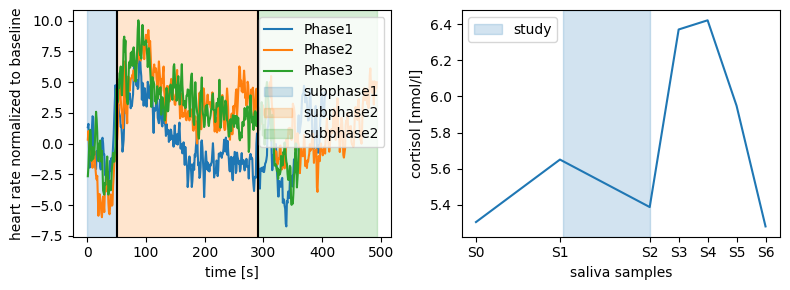

In [808]:
# run cell to visualize data
fig, axs = plt.subplots(ncols=2, figsize=(8, 3))
data_hr["Phase1"].mean(axis=1).plot(ax=axs[0], label="Phase1")
data_hr["Phase2"].mean(axis=1).plot(ax=axs[0], label="Phase2")
data_hr["Phase3"].mean(axis=1).plot(ax=axs[0], label="Phase3")
axs[0].axvline(50, color='k')
axs[0].axvline(290, color='k')
axs[0].axvspan(0, 49, alpha=0.2, color='tab:blue', label="subphase1")
axs[0].axvspan(50, 289, alpha=0.2, color='tab:orange', label="subphase2")
axs[0].axvspan(290, 493, alpha=0.2, color='tab:green', label="subphase2")
axs[0].set_xlabel("time [s]")
axs[0].set_ylabel("heart rate normalized to baseline")
axs[0].legend()

sample_times = np.array([-30, -1, 30, 40, 50, 60, 70])
axs[1].plot(sample_times, data_saliva.unstack().mean(axis=0).to_numpy())
axs[1].set_xticks(sample_times)
axs[1].set_xticklabels(["S0", "S1", "S2", "S3", "S4", "S5", "S6"])
axs[1].set_xlabel("saliva samples")
axs[1].set_ylabel("cortisol [nmol/l]")
axs[1].axvspan(0, 30, alpha=0.2, color='tab:blue', label="study")
axs[1].legend()
fig.tight_layout()

##### 2.1

In [702]:
### BEGIN SOLUTION
def drop_cols(data, cols):
    return data.drop(columns=cols)
### END SOLUTION

In [677]:
data_test = pd.DataFrame([[1, 2, 3], [4, 5, 6]], columns=["A", "B", "C"])
assert drop_participants(data_test, ["A"]).shape == (2, 2)
assert list(drop_participants(data_test, ["A"]).columns) == ["B", "C"]
assert list(drop_participants(data_test, ["A", "C"]).columns) == ["B"]

##### 2.1

In [641]:
### BEGIN SOLUTION
def calc_mean(data):
    data_mean = data.agg(["mean"], axis=0)
    data_mean.index = ["heart_rate"]
    return data_mean
### END SOLUTION

##### 2.2

In [642]:
### BEGIN SOLUTION
def create_multi_index(participants, condition, phase, subphase):
    phase_arr = np.array([phase] * len(participants))
    subphase_arr = np.array([subphase] * len(participants))
    index = pd.MultiIndex.from_arrays(
        [participants, condition, phase_arr, subphase_arr],
        names = ["participant", "condition", "phase", "subphase"]
    )
    return index
### END SOLUTION   

##### 2.3

In [718]:
subphases = {
    "Subphase1": {"start": 0, "stop": 49},
    "Subphase2": {"start": 50, "stop": 289},
    "Subphase3": {"start": 290, "stop": -1}
}
drop_participants = ["Vp07", "Vp22"]

### BEGIN SOLUTION
data_all = pd.DataFrame()

for phase in data_hr.keys():
    data = data_hr[phase]
    data = drop_cols(data, drop_participants)
    
    for subphase in subphases.keys():
        data_sub = data.iloc[subphases[subphase]["start"] : subphases[subphase]["stop"]]
        
        data_mean = calc_mean(data_sub)
        index = create_multi_index(data_mean.columns, list(data_condition["condition"]), phase, subphase)

        data_mean.columns = index
        data_mean = data_mean.T
        
        data_all = pd.concat([data_all, data_mean], axis=0)        
data_all = data_all.sort_index()
data_all.head()
### END SOLUTION

heart_rate
participant condition    phase  subphase             
Vp01        Intervention Phase1 Subphase1   -1.834143
                                Subphase2   -0.553887
                                Subphase3   -0.838475
                         Phase2 Subphase1   -1.695172
                                Subphase2   -2.130323

In [705]:
### BEGIN SOLUTION
def calc_mean_grouped(data, keys):
    return data.groupby(keys).mean()
### END SOLUTION

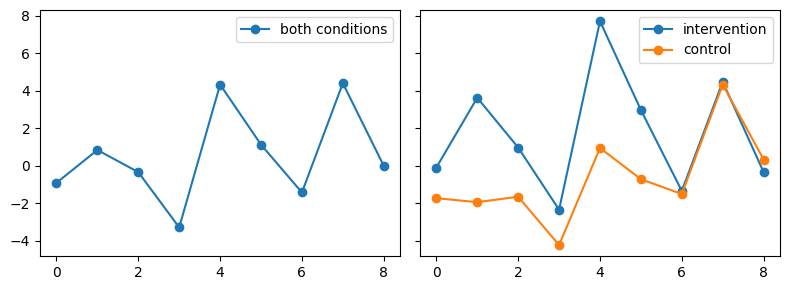

In [732]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 3), sharey=True)
data_mean = calc_mean_grouped(data_all, ["phase", "subphase"])
axs[0].plot(data_mean.to_numpy(), label="both conditions", marker='o')
axs[0].legend()
data_mean = calc_mean_grouped(data_all, ["condition", "phase", "subphase"])
axs[1].plot(data_mean.xs("Intervention", level="condition").to_numpy(), label="intervention", marker='o')
axs[1].plot(data_mean.xs("Control", level="condition").to_numpy(), label="control", marker='o')
axs[1].legend()
fig.tight_layout()

##### 2.X

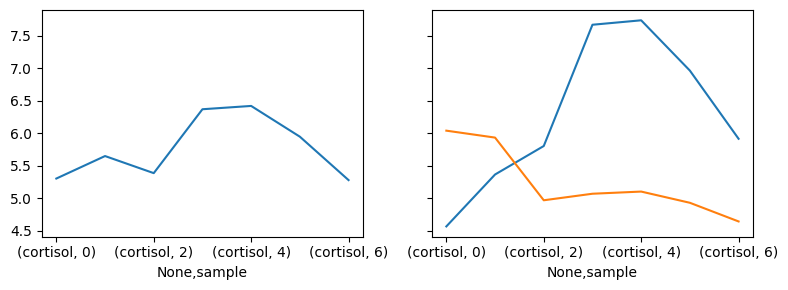

In [736]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 3), sharey=True)
data_saliva.unstack().mean(axis=0).plot(ax=axs[0])
data_saliva.xs("Control", level="condition").unstack().mean(axis=0).plot(ax=axs[1])
data_saliva.xs("Intervention", level="condition").unstack().mean(axis=0).plot(ax=axs[1])
fig.tight_layout()

In [772]:
res = (df_2["max"] - df_1["cortisol"])
_res = res.to_numpy()

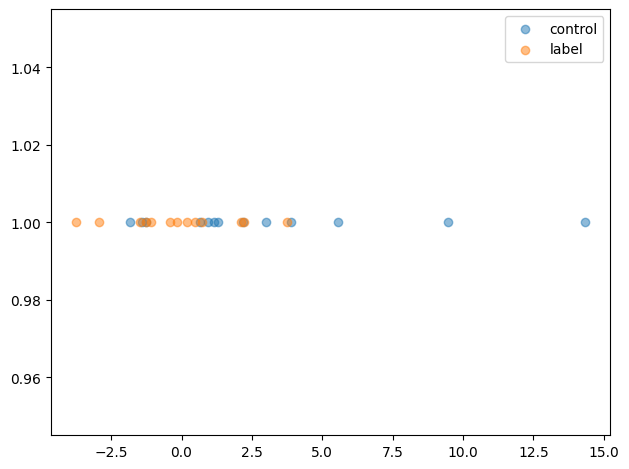

In [800]:
condition = res.reset_index()["condition"]
res_cont = _res[(condition == "Control").to_numpy()]
res_int = _res[(condition == "Intervention").to_numpy()]
fig, axs = plt.subplots()
axs.scatter(res_cont, np.ones(np.shape(res_cont)), color="tab:blue", label="control", alpha=0.5)
axs.scatter(res_int, np.ones(np.shape(res_int)), color="tab:orange", label="label", alpha=0.5)
axs.legend()
fig.tight_layout()

In [763]:
df_1 = data_saliva.xs("1", level="sample")
df_2 = data_saliva.unstack().cortisol[["2", "3", "4", "5", "6"]].agg(["max"], axis=1)

In [801]:
data_saliva.drop("0", level="sample")

cortisol
condition    subject sample          
Intervention Vp01    1        7.03320
                     2        5.77670
                     3        5.25790
                     4        5.00795
                     5        4.50045
...                               ...
Control      Vp33    2        7.78115
                     3        8.74815
                     4        7.66505
                     5        7.75460
                     6        6.72890

[156 rows x 1 columns]

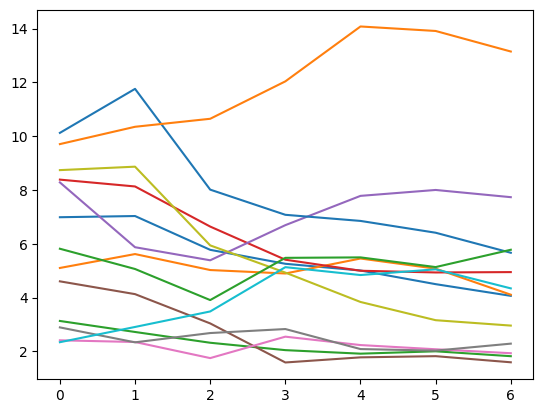

In [806]:
plt.plot(data_saliva.xs("Intervention", level="condition").unstack().to_numpy().T)

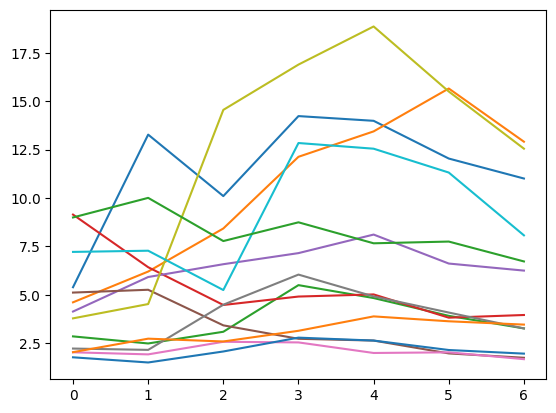

In [807]:
plt.plot(data_saliva.xs("Control", level="condition").unstack().to_numpy().T)